## Group ID: 22
*   Taha El Amine Kassabi
*   Mohamed Hazem Badawi
*   Carolin Goj

## Exercise day: Tuesday

# Exercise 13: GPTrump challenge
In this exercise, you will be given a pretrained GPT1 model and a list of Trump speeches. Your task is to generate a speech (or at least a few paragraphs that could be a part of it) that is similar to Trump's speeches. You should fine-tune the GPT1 model on the given speeches and then generate a new speech using the fine-tuned model. The code to obtain the pretrained weights will be given. You are only allowed to use the given speeches for fine-tuning the model. (see the `speeches.txt` file)

The final generated speech which you want to submit must be 200 tokens long. But you are allowed to use a more clever beginning of the speech to make it more coherent, but the beginning must not exceed a length of `10` tokens. Also all other parameters of the `generate` function can be changed. And you can even come up with a more sophisticated way to generate the speech as long as you use your fine-tuned model outputs.

The evaluation (the points you get for this exercise sheet) will be based on the perplexity of your model. Please save and submit your final model using the provided code in the `Submission` section. We will not run the training code.

The challenge itself is just based on the one submitted speech. The cell output of the generate function call in section `Submission` will be used. To build a leaderboard, we will compare the submissions 1 vs 1. The submission which seems more Trump-like will win. (like [lmarena](https://lmarena.ai/?leaderboard))

Disclaimer: The task is just for educational purposes and is not meant to offend anyone. The task is just to generate a speech that is similar to Trump's speeches.

In [2]:
### Do not change this code cell ###

from tqdm.auto import tqdm, trange
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from transformers import OpenAIGPTConfig, OpenAIGPTDoubleHeadsModel, AutoTokenizer
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

configuration = OpenAIGPTConfig()
tokenizer = AutoTokenizer.from_pretrained("openai-community/openai-gpt")

model = OpenAIGPTDoubleHeadsModel.from_pretrained("openai-community/openai-gpt").to(device)
inputs = tokenizer("I am Donald Trump and I will", return_tensors="pt")


class CustomTextDataset(Dataset):
    def __init__(self, data, blocksize):
        self.data = data
        self.blocksize = blocksize

    def __len__(self):
        return (len(self.data) - 1) // self.blocksize

    def __getitem__(self, idx):
        assert idx + self.blocksize + 1 < len(self.data), "idx too large"
        context = self.data[idx * self.blocksize:(idx + 1) * self.blocksize]
        target = self.data[idx * self.blocksize + 1:(idx + 1) * self.blocksize + 1]
        return context, target


blocksize = 512
batchsize = 4

text = open("speeches.txt").read()

for i in range(len(text) // 512):
    x = torch.tensor(tokenizer.encode(text[i * 512:(i + 1) * 512]))
    data = x if i == 0 else torch.cat((data, x))

dataloader = DataLoader(CustomTextDataset(data, blocksize), batch_size=batchsize)

print(len(dataloader))
for i, (context, target) in enumerate(dataloader):
    print(f"Context: \n{context} \nTarget:\n{target}")
    if i >= 4:
        break

cuda


Some weights of OpenAIGPTDoubleHeadsModel were not initialized from the model checkpoint at openai-community/openai-gpt and are newly initialized: ['multiple_choice_head.summary.bias', 'multiple_choice_head.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


499
Context: 
tensor([[1784,  512, 4855,  ...,  504,  797,  488],
        [ 797, 2074,  239,  ...,  862,  240,  606],
        [4676,  507,  239,  ..., 2972, 9524,  488],
        [7197, 9557,  239,  ...,  600,  256,  716]]) 
Target:
tensor([[ 512, 4855,  239,  ...,  797,  488,  797],
        [2074,  239,  500,  ...,  240,  606, 4676],
        [ 507,  239,  606,  ..., 9524,  488, 7197],
        [9557,  239,  606,  ...,  256,  716,  797]])
Context: 
tensor([[  797,   485,  3013,  ...,   239,   606,   823],
        [  485,   921,  1533,  ...,   770,   485,  5432],
        [ 9860,  7876,   239,  ...,   239, 17621,  2820],
        [ 4312,  6001,   239,  ...,   963,   889,   239]]) 
Target:
tensor([[  485,  3013,   704,  ...,   606,   823,   485],
        [  921,  1533,   498,  ...,   485,  5432,  9860],
        [ 7876,   239,   525,  ..., 17621,  2820,  4312],
        [ 6001,   239,  2820,  ...,   889,   239,  1784]])
Context: 
tensor([[ 1784,   512,   240,  ...,   889,   509,   507],
      

In [3]:
def generate(model, prompt, top_k=50, max_length=32, num_return_sequences=4):
    model.eval()
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long)
    tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
    xgen = tokens.to(device)
    sample_rng = torch.Generator(device=device)
    sample_rng.manual_seed(42)
    while xgen.size(1) < max_length:
        with torch.no_grad():
            outputs = model(xgen)
            # take the logits at the last position
            logits = outputs.logits[:, -1, :]  # (B, vocab_size)
            # get the probabilities
            probs = F.softmax(logits, dim=-1)
            # do top-k sampling of 50 (huggingface pipeline default)
            # topk_probs here becomes (5, 50), topk_indices is (5, 50)
            topk_probs, topk_indices = torch.topk(probs, top_k, dim=-1)
            # select a token from the top-k probabilities
            # note: multinomial does not demand the input to sum to 1
            ix = torch.multinomial(topk_probs, 1, generator=sample_rng)  # (B, 1)
            # gather the corresponding indices
            xcol = torch.gather(topk_indices, -1, ix)  # (B, 1)
            # append to the sequence
            xgen = torch.cat((xgen, xcol), dim=1)
    # print the generated text
    for i in range(num_return_sequences):
        tokens = xgen[i, :max_length].tolist()
        decoded = tokenizer.decode(tokens)
        print(f"sample {i}: {decoded}")


generate(model, "I am Donald Trump and I will", max_length=32)


sample 0: i am donald trump and i will be your agent . i 've had no sleep - in in weeks and today , i was summoned in the presence of mr. sanders
sample 1: i am donald trump and i will lead and you will follow . i love you and are n't afraid to try my luck with you , okay ? " 
 "
sample 2: i am donald trump and i will not be parted from you - ever again . this is my land now , and i am not going to let anyone have it
sample 3: i am donald trump and i will be an important one . " he had the attention of the entire room . he stepped in close and his voice dropped from a


## Training
You have to implement the fine-tuning of the model here

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/499 [00:00<?, ?it/s]

Epoch 1/3, Loss: 3.0704038917182204


  0%|          | 0/499 [00:00<?, ?it/s]

Epoch 2/3, Loss: 2.6987283387499486


  0%|          | 0/499 [00:00<?, ?it/s]

Epoch 3/3, Loss: 2.4751076277845607


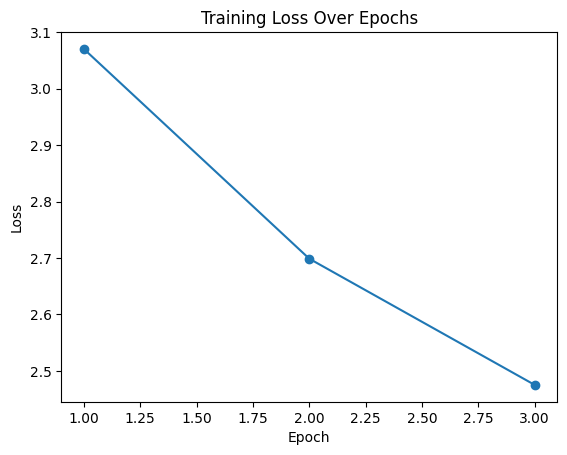

In [4]:
# Training loop
## Your code here ##

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5)

num_epochs = 3
loss_values = []

for epoch in trange(num_epochs):
    model.train()
    running_loss = 0.0

    for context, target in tqdm(dataloader):
        context = context.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        outputs = model(context)
        logits = outputs.logits
        logits = logits.view(-1, logits.size(-1))
        target = target.view(-1)

        loss = criterion(logits, target)
        loss.backward()

        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss}")

plt.plot(range(1, num_epochs + 1), loss_values, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

## Evaluation

In [5]:
def perplexity(model, dataloader):
    model = model.to(device)
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for context, target in tqdm(dataloader):
        context = context.to(device)
        target = target.to(device)

        pred = model(context).logits

        loss = F.cross_entropy(pred.reshape(-1, pred.shape[-1]), target.reshape(-1), reduction='sum')
        total_loss += loss.item()
        total_tokens += target.numel()

    return torch.exp(torch.tensor(total_loss / total_tokens)).item()


print(perplexity(model, dataloader))

  0%|          | 0/499 [00:00<?, ?it/s]

9.22572135925293


## Submission

In [6]:
generate(model, "I am Donald Trump and I will", max_length=200, num_return_sequences=1)

sample 0: i am donald trump and i will fight for every citizen , of every background , from every stretch of this nation . i will fight for every single citizen and i will fight to bring us all together as americans . we will make america great again , okay ? we will make america great again . thank you , everybody . thank you . it was so great to be here . the speeches went on for about 5 or 6 hours , one of them actually , was the trump speech . and i don ' t want to bring the criticism , but nobody would be more appropriate if i announced it , and i won ' t say anything but the bottom line , i won ' t mention names or the names , because i ' m not getting any credit for what i ' ve done , the way i ' ve treated you . but we ' re going to do things on a level you never thought possible ; we ' re going to make america great again . we ' re going to make great again . but we '


In [7]:
# save the model
model.save_pretrained("trump_model")

In [8]:
# load the model
model = OpenAIGPTDoubleHeadsModel.from_pretrained("trump_model").to(device)